In [8]:
import sys
print(sys.executable)

/Users/dionlajqi/Documents/GitHub/Dave3625-Host-2025/Lab2/.venv/bin/python


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [10]:
#OPPGAVE 1

#Import csv file
url = '/Users/dionlajqi/Documents/GitHub/Dave3625-Host-2025/Lab2/data/stud.csv'
df = pd.read_csv(url, sep=',')

df.head()


,StudentID,Age,email,hrsStudy,FinalGrade
0,47412,20,s47412@oslomet.no,5,46.0
1,15077,22,s15077@oslomet.no,0,65.0
2,15467,27,s15467@oslomet.no,1,26.0
3,17907,21,s17907@oslomet.no,6,68.0
4,13352,333,s13352@oslomet.no,4,34.0


In [11]:
df.isna().sum()

StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    1
dtype: int64

In [12]:
df.describe()

,StudentID,FinalGrade
count,50.000000,49.000000
mean,48969.820000,71.653061
std,26870.066326,90.455917
min,10736.000000,24.000000
25%,26666.500000,39.000000
50%,44292.000000,60.000000
75%,70400.250000,78.000000
max,99823.000000,673.000000


In [13]:
#Lets first replace all empty cells wit np.nan
df=df.replace(r'^\s*$', np.nan, regex=True)
#and check again
df.isna().sum()

StudentID     0
Age           1
email         0
hrsStudy      1
FinalGrade    1
dtype: int64

In [14]:


# Erstatt manglende Age med 0
df["Age"] = df["Age"].fillna(0)

# Fjern rader som fortsatt mangler viktige verdier
df.dropna(inplace=True)

# Konverter de numeriske kolonnene
df["Age"] = df["Age"].astype(int)
df["hrsStudy"] = df["hrsStudy"].astype(int)


In [15]:
df.isna().sum()

StudentID     0
Age           0
email         0
hrsStudy      0
FinalGrade    0
dtype: int64

In [16]:
df.info()
df.describe(
)

<class 'pandas.DataFrame'>
Index: 48 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   48 non-null     int64  
 1   Age         48 non-null     int64  
 2   email       48 non-null     str    
 3   hrsStudy    48 non-null     int64  
 4   FinalGrade  48 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 2.2 KB


,StudentID,Age,hrsStudy,FinalGrade
count,48.000000,48.000000,48.000000,48.000000
mean,50338.166667,35.666667,6.395833,72.083333
std,26526.981827,52.388619,3.648022,91.362461
min,11758.000000,0.000000,0.000000,24.000000
25%,28399.750000,22.000000,3.000000,38.750000
50%,45986.500000,25.000000,7.000000,61.000000
75%,71524.000000,31.000000,10.000000,78.500000
max,99823.000000,333.000000,11.000000,673.000000


<Axes: >

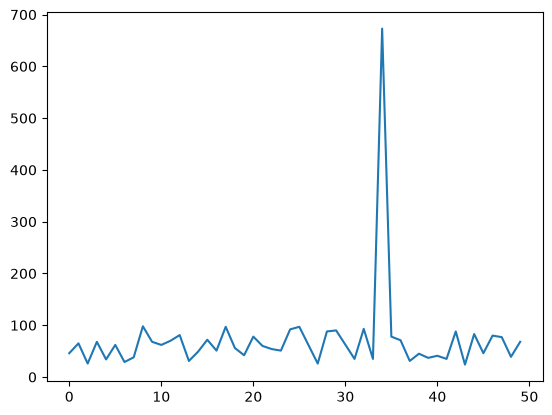

In [17]:
df["FinalGrade"].plot.line()

In [18]:
z_scores = stats.zscore(df["FinalGrade"])
abs_z_scores = np.abs(z_scores)

df.drop(df[abs_z_scores > 3].index, inplace=True)


<Axes: >

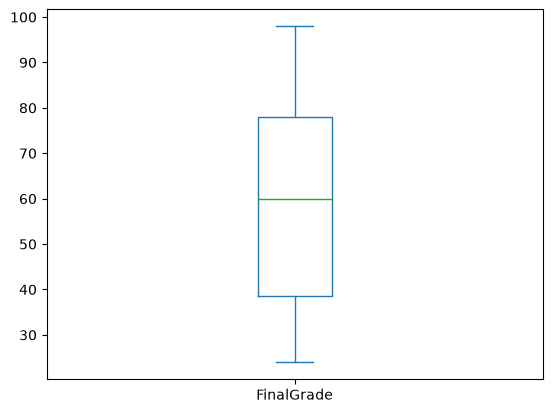

In [19]:
df["FinalGrade"].plot.box()

In [20]:
df.tail()

,StudentID,Age,email,hrsStudy,FinalGrade
45,62039,23,s62039@oslomet.no,4,46.0
46,42989,27,s42989@oslomet.no,0,80.0
47,85370,29,s85370@oslomet.no,2,77.0
48,63135,26,s63135@oslomet.no,9,39.0
49,28895,19,s28895@oslomet.no,10,68.0


In [21]:
#As you can see, the index counts to 49, but we have dropped several values.. to reset the index you can use
df = df.reset_index(drop=True)
df.tail(5)

,StudentID,Age,email,hrsStudy,FinalGrade
42,62039,23,s62039@oslomet.no,4,46.0
43,42989,27,s42989@oslomet.no,0,80.0
44,85370,29,s85370@oslomet.no,2,77.0
45,63135,26,s63135@oslomet.no,9,39.0
46,28895,19,s28895@oslomet.no,10,68.0


In [22]:
# create a list of our conditions
conditions = [
    (df['FinalGrade'] <= 50.0),
    (df['FinalGrade'] > 50.0) & (df['FinalGrade'] <= 60.0),
    (df['FinalGrade'] > 60.0) & (df['FinalGrade'] <= 70.0),
    (df['FinalGrade'] > 70.0) & (df['FinalGrade'] <= 80.0),
    (df['FinalGrade'] > 80.0) & (df['FinalGrade'] <= 90.0),
    (df['FinalGrade'] > 90.0)
    ]

# create a list of the values we want to assign for each condition
values = ["F", "E", "D", "C", "B", "A"]

df["Grade"] = np.select(
    conditions,
    values,
    default="Unknown"
)

# display updated DataFrame
df.head()

,StudentID,Age,email,hrsStudy,FinalGrade,Grade
0,47412,20,s47412@oslomet.no,5,46.0,F
1,15077,22,s15077@oslomet.no,0,65.0,D
2,15467,27,s15467@oslomet.no,1,26.0,F
3,17907,21,s17907@oslomet.no,6,68.0,D
4,13352,333,s13352@oslomet.no,4,34.0,F


In [23]:
df_gradeCount = df.groupby("Grade").count()
df_gradeCount.FinalGrade

Grade
A     5
B     5
C     6
D     7
E     5
F    19
Name: FinalGrade, dtype: int64

<Axes: xlabel='Grade'>

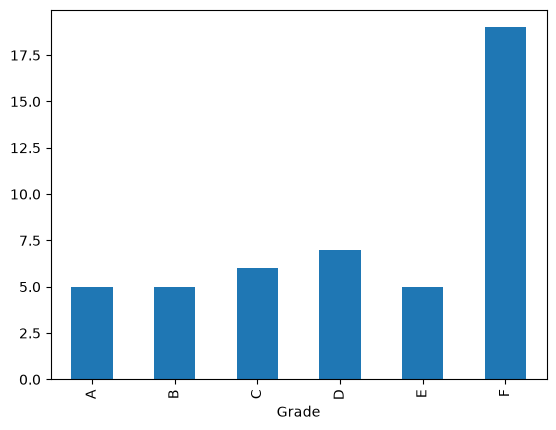

In [24]:
df_gradeCount.FinalGrade.plot.bar()